<a href="https://colab.research.google.com/github/yenhoang1102/House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


TIỀN XỬ LÍ DỮ LIỆU


In [2]:
import numpy as np
import pandas as pd
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')
#mô tả cấu trúc dữ liệu của tập train

#xử lí giá trị thiếu
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

for col in ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
            'Electrical', 'KitchenQual', 'Functional', 'SaleType']:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

for col in ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
            'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
            'GarageCars', 'GarageArea']:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

print(train.shape)
print(test.shape)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
all_data = pd.concat([train.drop(['SalePrice'], axis=1), test], axis=0)
all_data = pd.get_dummies(all_data, drop_first=True)
train_encoded = all_data.iloc[:len(train), :].copy()
test_encoded = all_data.iloc[len(train):, :].copy()
from sklearn.preprocessing import OneHotEncoder
from pandas import get_dummies
train_encoded = get_dummies(train_encoded, drop_first=True)
test_encoded = get_dummies(test_encoded, drop_first=True)

# Chuẩn hóa
scaler = StandardScaler()
numerical_cols = train_encoded.drop(['Id'],axis=1)
numerical_column_names = numerical_cols.columns
# Apply the scaler to the selected numerical columns
train_encoded[numerical_column_names] = scaler.fit_transform(train_encoded[numerical_column_names])
test_encoded[numerical_column_names] = scaler.transform(test_encoded[numerical_column_names])

print("Mô tả dữ liệu sau chuẩn hóa")
print(train_encoded.describe())
print(test_encoded.describe())
X = train_encoded.drop(['Id'], axis=1)
target_scaler = StandardScaler()
y = train['SalePrice']
y = target_scaler.fit_transform(y.values.reshape(-1, 1))
y = y.flatten()
print(X.describe())
import matplotlib.pyplot as plt
import seaborn as sns



(1460, 81)
(1459, 80)
Mô tả dữ liệu sau chuẩn hóa
                Id    MSSubClass   LotFrontage       LotArea   OverallQual  \
count  1460.000000  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03   
mean    730.500000 -8.455945e-17  2.798370e-16 -5.840077e-17  1.387018e-16   
std     421.610009  1.000343e+00  1.000343e+00  1.000343e+00  1.000343e+00   
min       1.000000 -8.725628e-01 -2.219047e+00 -9.237292e-01 -3.688413e+00   
25%     365.750000 -8.725628e-01 -4.479400e-01 -2.969908e-01 -7.951515e-01   
50%     730.500000 -1.631095e-01 -3.922314e-02 -1.040633e-01 -7.183611e-02   
75%    1095.250000  3.098594e-01  4.149067e-01  1.087080e-01  6.514792e-01   
max    1460.000000  3.147673e+00  1.104155e+01  2.051827e+01  2.821425e+00   

        OverallCond     YearBuilt  YearRemodAdd    MasVnrArea    BsmtFinSF1  \
count  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03   
mean   3.540547e-16  1.046347e-15  4.496860e-15 -3.893385e-17 -2.433366e-17   
std    1.0

GIẢM CHIỀU BẰNG PHƯƠNG PHÁP PCA


Số cột bị loại bỏ: 0
Số cột còn lại: 258
Số đặc trưng được chọn: 30
Các đặc trưng được chọn: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'OpenPorchSF', 'ExterQual_Gd', 'ExterQual_TA', 'Foundation_PConc', 'BsmtQual_Gd', 'BsmtQual_TA', 'KitchenQual_Gd', 'KitchenQual_TA', 'FireplaceQu_None', 'GarageType_Attchd', 'GarageFinish_Unf']
Tỷ lệ phương sai giữ lại: 0.9616406245277429


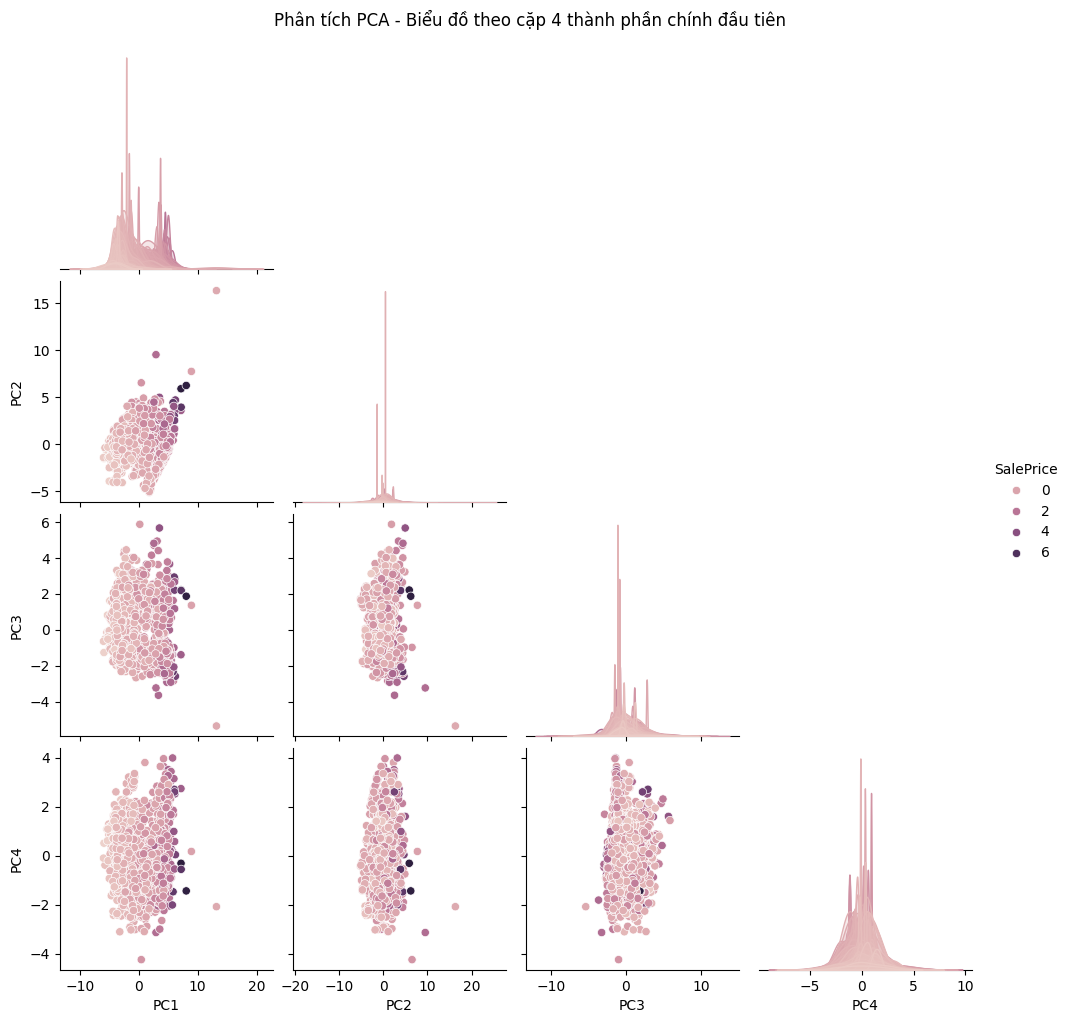

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
import numpy as np

variances = X.var()
low_variance_cols = variances[variances < 0.01].index
X_filtered = X.drop(low_variance_cols, axis=1)
print(f"Số cột bị loại bỏ: {len(low_variance_cols)}")
print(f"Số cột còn lại: {X_filtered.shape[1]}")

# Chọn k đặc trưng (ví dụ: 30)
selector = SelectKBest(score_func=mutual_info_regression, k=30)
X_selected = selector.fit_transform(X_filtered, y) # Tạo X_selected
selected_features = X_filtered.columns[selector.get_support()].tolist()
print(f"Số đặc trưng được chọn: {len(selected_features)}")
print(f"Các đặc trưng được chọn: {selected_features}")

# 3. Chuẩn hóa toàn bộ dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# 4. Áp dụng PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)
print("Tỷ lệ phương sai giữ lại:", sum(pca.explained_variance_ratio_))

# 5. Vẽ lại pairplot (nếu cần)
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(20)])
pca_df['SalePrice'] = y

# Vẽ pairplot cho 4 thành phần đầu tiên
sns.pairplot(pca_df, vars=['PC1', 'PC2', 'PC3', 'PC4'], hue='SalePrice', corner=True)
plt.suptitle("Phân tích PCA - Biểu đồ theo cặp 4 thành phần chính đầu tiên", y=1.02)
plt.show()

[0.32927263 0.11303112 0.08204787 0.04831032 0.0464924  0.03561591
 0.03492676 0.03320483 0.02926894 0.02815749 0.02546753 0.02318501
 0.02161738 0.02088358 0.01931719 0.01635815 0.01427195 0.01269334
 0.01073614 0.00989102]
Tổng lượng thông tin bảo tồn với 4 thành phần chính: 95.47%


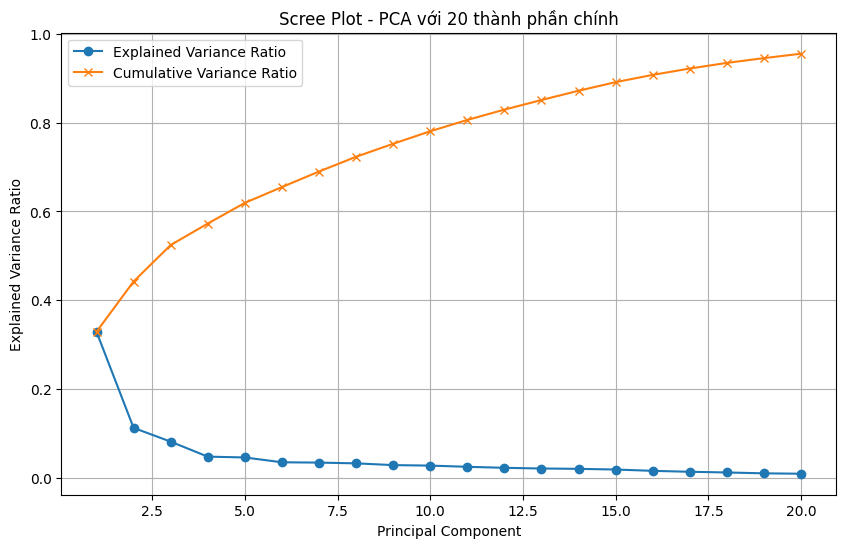

In [ ]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)
total_explained = explained_variance.sum()
print(f"Tổng lượng thông tin bảo tồn với 4 thành phần chính: {total_explained:.2%}")
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), pca.explained_variance_ratio_, marker='o', label='Explained Variance Ratio')
plt.plot(range(1, 21), np.cumsum(pca.explained_variance_ratio_), marker='x', label='Cumulative Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - PCA với 20 thành phần chính')
plt.legend()
plt.grid(True)
plt.show()

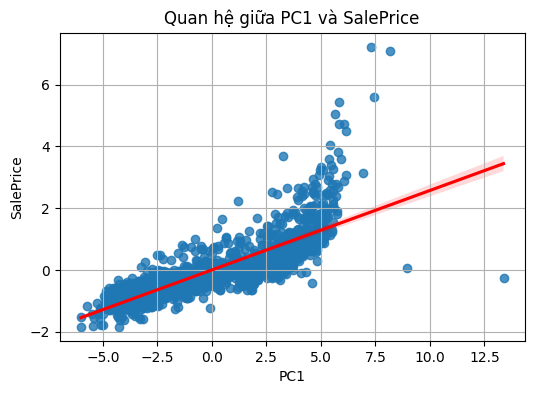

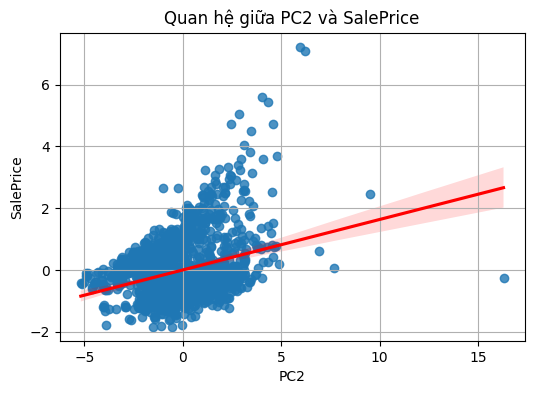

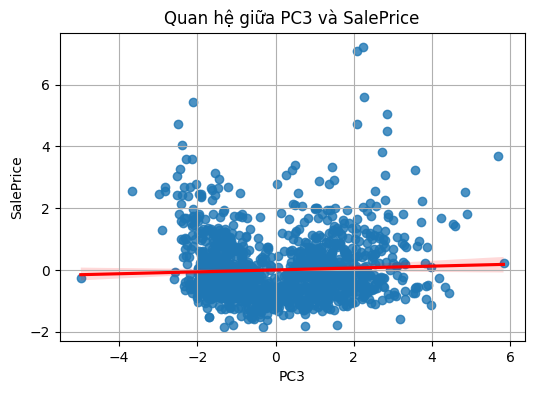

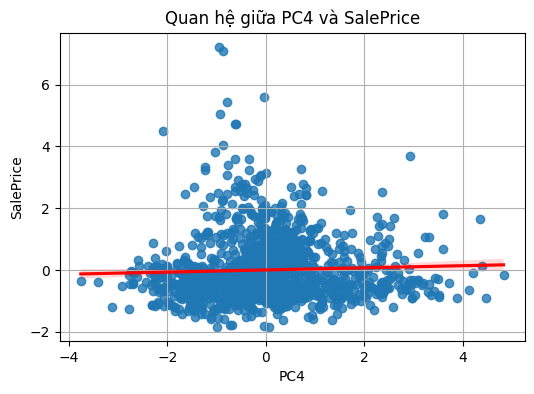

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['SalePrice'] = y  # hoặc y.reset_index(drop=True)

# Vẽ biểu đồ phân tán giữa một số thành phần chính với SalePrice
selected_pcs = ['PC1', 'PC2', 'PC3', 'PC4']  # Chọn 4 thành phần đầu
for pc in selected_pcs:
    plt.figure(figsize=(6, 4))
    sns.regplot(data=pca_df, x=pc, y='SalePrice', line_kws={'color':'red'})
    plt.title(f'Quan hệ giữa {pc} và SalePrice')
    plt.grid(True)
    plt.show()

GIẢM CHIỀU BẰNG PHƯƠNG PHÁP LDA


Số thành phần LDA tối đa có thể: 3


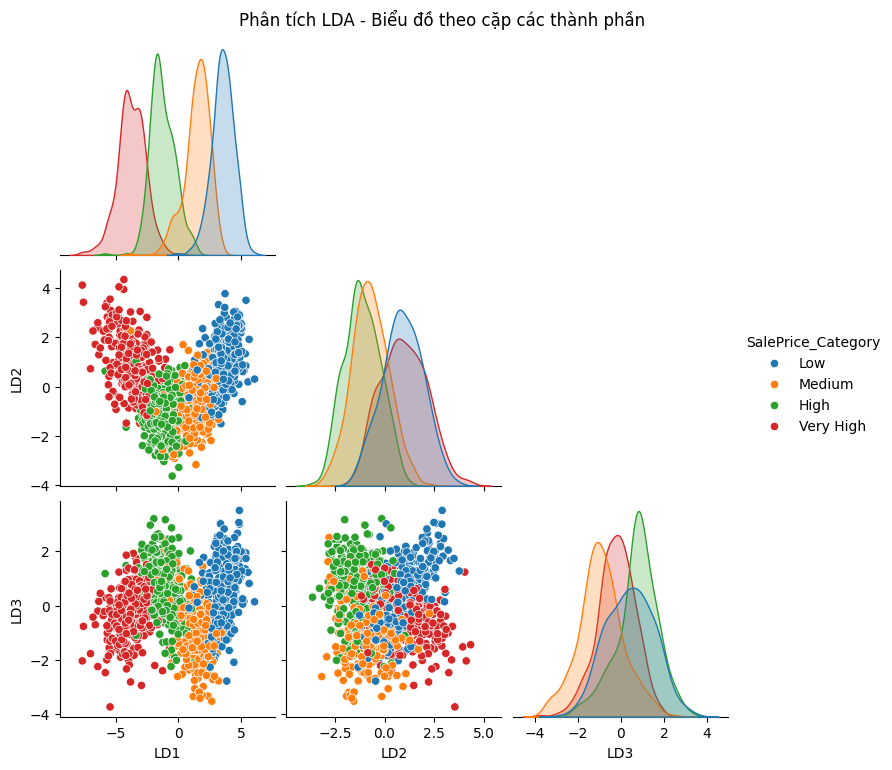

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
y_cat = pd.qcut(y, q=4, labels=['Low', 'Medium', 'High', 'Very High'])


# Giảm chiều bằng LDA
n_classes = len(y_cat.unique())
n_features = X.shape[1]
n_components = min(n_classes - 1, n_features)  # Tối đa 3 thành phần
print(f"\nSố thành phần LDA tối đa có thể: {n_components}")
lda = LDA(n_components=n_components)
X_lda = lda.fit_transform(X, y_cat)
lda_df = pd.DataFrame(X_lda, columns=[f'LD{i+1}' for i in range(X_lda.shape[1])])
lda_df['SalePrice'] = y
lda_df['SalePrice_Category'] = y_cat
sns.pairplot(lda_df, vars=[f'LD{i+1}' for i in range(X_lda.shape[1])], hue='SalePrice_Category', corner=True)
plt.suptitle("Phân tích LDA - Biểu đồ theo cặp các thành phần", y=1.02)
plt.show()


[0.85272008 0.10075434 0.04652558]
Tổng lượng thông tin bảo tồn với 3 thành phần chính: 100.00%


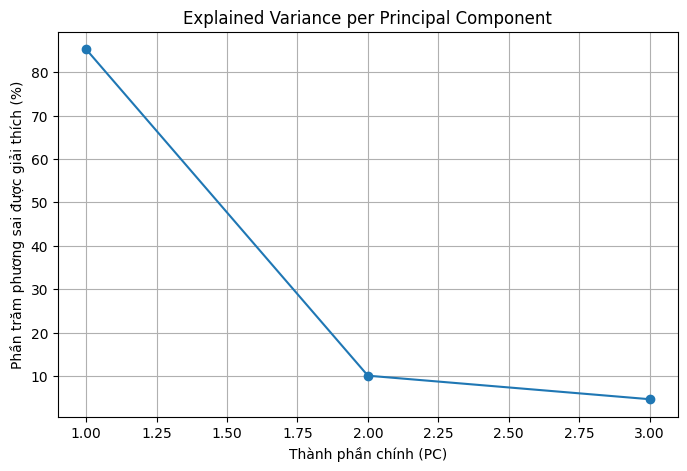

In [ ]:
explained_variance = lda.explained_variance_ratio_
print(explained_variance)
total_explained = explained_variance.sum()
print(f"Tổng lượng thông tin bảo tồn với 3 thành phần chính: {total_explained:.2%}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 4), explained_variance * 100, 'o-')
plt.xlabel('Thành phần chính (PC)')
plt.ylabel('Phần trăm phương sai được giải thích (%)')
plt.title('Explained Variance per Principal Component')
plt.grid(True)
plt.show()

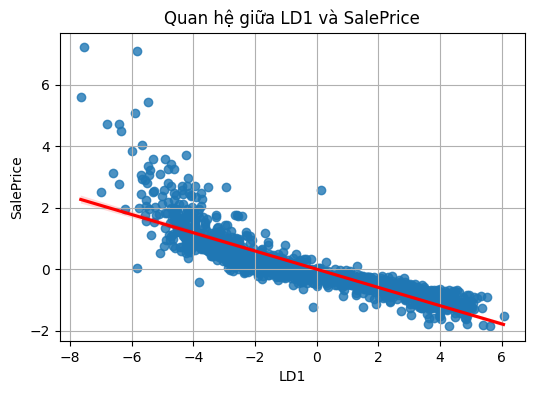

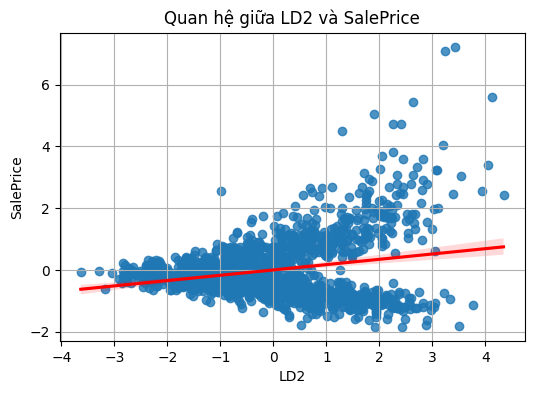

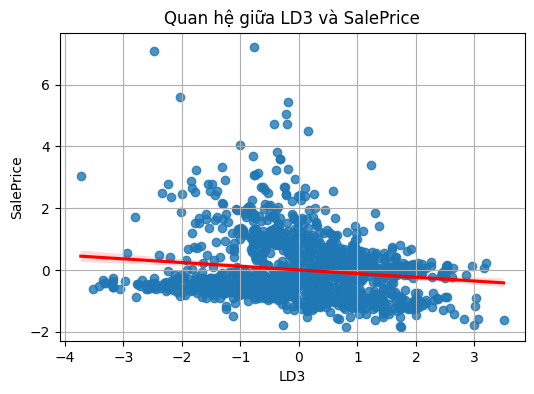

In [ ]:
lda_df = pd.DataFrame(X_lda, columns=[f'LD{i+1}' for i in range(X_lda.shape[1])])
lda_df['SalePrice'] = y
lda_df['SalePrice_Category'] = y_cat
# Vẽ biểu đồ phân tán giữa một số thành phần chính với SalePrice
for ld in lda_df.columns[:-2]:
    plt.figure(figsize=(6, 4))
    sns.regplot(data=lda_df, x=ld, y='SalePrice', line_kws={'color': 'red'})
    plt.title(f'Quan hệ giữa {ld} và SalePrice')
    plt.xlabel(ld)
    plt.ylabel('SalePrice')
    plt.grid(True)
    plt.show()

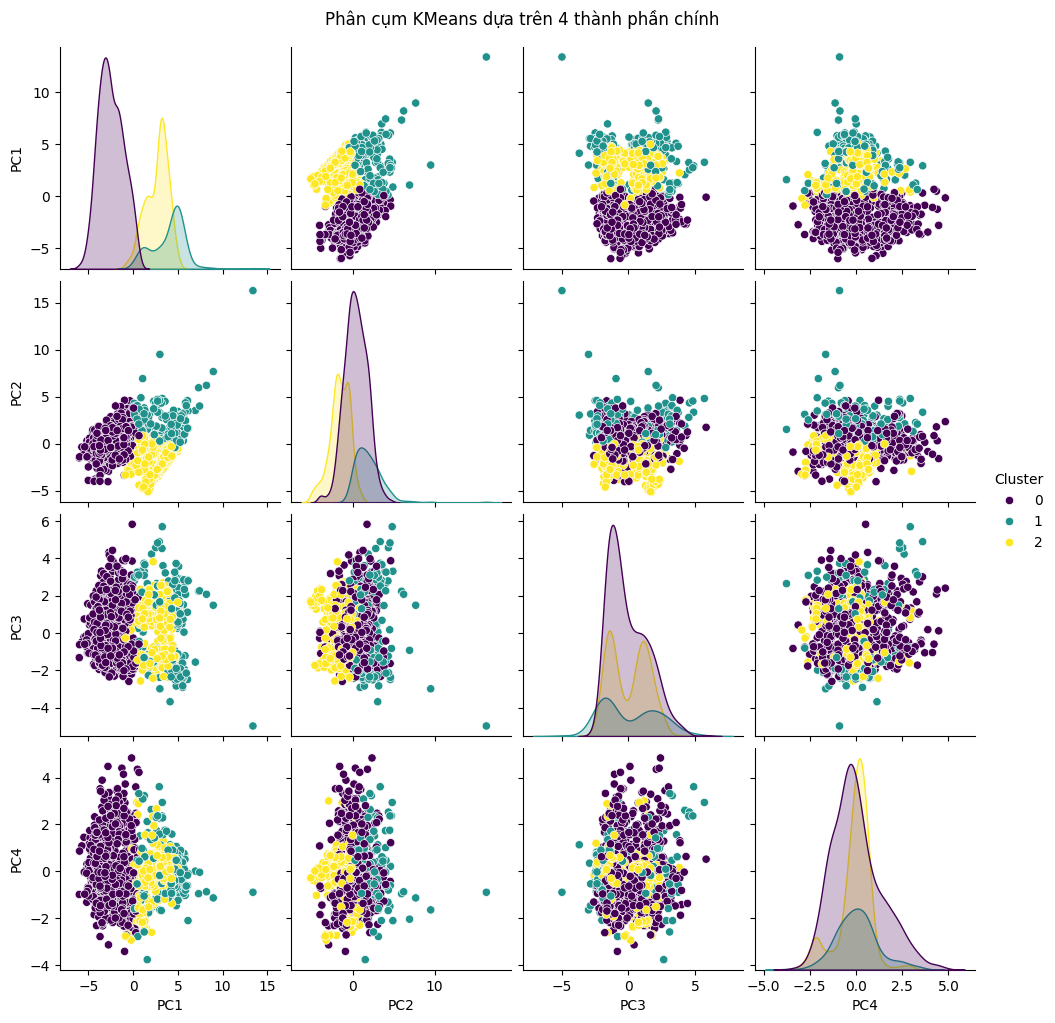

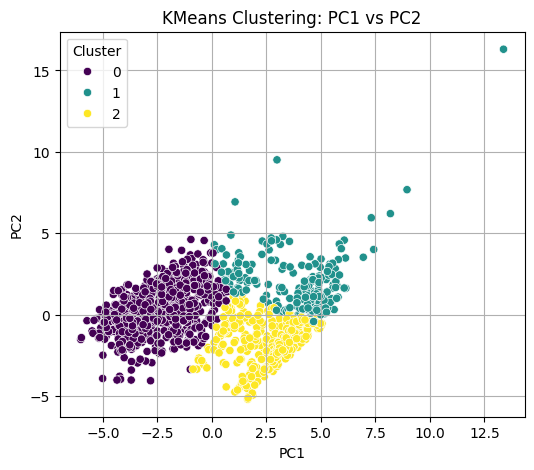

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_pca)
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(20)])
pca_df['Cluster'] = clusters
sns.pairplot(pca_df, hue='Cluster', vars=['PC1', 'PC2', 'PC3', 'PC4'], palette='viridis')
plt.suptitle("Phân cụm KMeans dựa trên 4 thành phần chính", y=1.02)
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title("KMeans Clustering: PC1 vs PC2")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
silhouette = silhouette_score(X_pca, clusters)
davies_bouldin = davies_bouldin_score(X_pca, clusters)
calinski_harabasz = calinski_harabasz_score(X_pca, clusters)
print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Score: {davies_bouldin}")
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

Silhouette Score: 0.207093019053122
Davies-Bouldin Score: 1.9641047512271843
Calinski-Harabasz Score: 354.2578938212555


 DBScan

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=4)
labels = dbscan.fit_predict(X_pca)
mask = labels != -1
score = silhouette_score(X_pca[mask], labels[mask])
dbi = davies_bouldin_score(X_pca[mask],labels[mask])
print("Silhouette Score (không tính outliers):", score)
print("Davies-Bouldin Score (không tính outliers):", dbi)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Số cụm được phát hiện:", n_clusters)

Silhouette Score (không tính outliers): 0.8967370668017315
Davies-Bouldin Score (không tính outliers): 0.12880819351544665
Số cụm được phát hiện: 2


CHIA TẬP DỮ LIỆU

In [ ]:

X1_train, X1_val, y1_train, y1_val = train_test_split(X, y, test_size=0.1, random_state=42)
X1_pca_train,X1_pca_val,y1_pca_train,y1_pca_val = train_test_split(X_pca, y, test_size=0.1, random_state=42)
X2_train, X2_val, y2_train, y2_val = train_test_split(X, y, test_size=0.3, random_state=42)
X2_pca_train,X2_pca_val,y2_pca_train,y2_pca_val = train_test_split(X_pca, y, test_size=0.3, random_state=42)
X3_train, X3_val, y3_train, y3_val = train_test_split(X, y, test_size=0.4, random_state=42)
X3_pca_train,X3_pca_val,y3_pca_train,y3_pca_val = train_test_split(X_pca, y, test_size=0.4, random_state=42)
#phương pháp hồi quy LinearRegression với train:val
print("phương pháp hồi quy LinearRegression với train:val = 9:1")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.model_selection import cross_val_score
model = LinearRegression()
model.fit(X1_train, y1_train)
y1_pred = model.predict(X1_val)
mse1 = mean_squared_error(y1_val, y1_pred)
r2_1 = r2_score(y1_val, y1_pred)
print(f'Mean Squared Error trên tập val với dữ liệu gốc (MSE): {mse1}')
print(f'R-squared trên tập val với dữ liệu gốc (R2): {r2_1}')
model.fit(X1_pca_train, y1_pca_train)
y1_pca_pred = model.predict(X1_pca_val)
mse1_pca = mean_squared_error(y1_pca_val, y1_pca_pred)
r2_1_pca = r2_score(y1_pca_val, y1_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse1_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_1_pca}')


phương pháp hồi quy LinearRegression với train:val = 9:1
Mean Squared Error trên tập val với dữ liệu gốc (MSE): 0.15256285910739395
R-squared trên tập val với dữ liệu gốc (R2): 0.8946897635157307
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 0.24941604213938942
R-squared với dữ liệu đã giảm chiều (R2): 0.8278344904235175


In [ ]:
print("phương pháp hồi quy LinearRegression với train:val = 7:3")
model = LinearRegression()
model.fit(X2_train, y2_train)
y2_pred = model.predict(X2_val)
mse1 = mean_squared_error(y2_val, y2_pred)
r2_1 = r2_score(y2_val, y2_pred)
print(f'Mean Squared Error với dữ liệu gốc (MSE): {mse1}')
print(f'R-squared với dữ liệu gốc (R2): {r2_1}')
model.fit(X2_pca_train, y2_pca_train)
y2_pca_pred = model.predict(X2_pca_val)
mse2_pca = mean_squared_error(y2_pca_val, y2_pca_pred)
r2_2_pca = r2_score(y2_pca_val, y2_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse2_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_2_pca}')


phương pháp hồi quy LinearRegression với train:val = 7:3
Mean Squared Error với dữ liệu gốc (MSE): 1.0807084826630093
R-squared với dữ liệu gốc (R2): 0.023257617903980288
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 0.18931019617784675
R-squared với dữ liệu đã giảm chiều (R2): 0.8289017853231071


In [ ]:
print("phương pháp hồi quy LinearRegression với train:val = 6:4")
model = LinearRegression()
model.fit(X3_train, y3_train)
y3_pred = model.predict(X3_val)
mse1 = mean_squared_error(y3_val, y3_pred)
r2_1 = r2_score(y3_val, y3_pred)
print(f'Mean Squared Error với dữ liệu gốc (MSE): {mse1}')
print(f'R-squared với dữ liệu gốc (R2): {r2_1}')
model.fit(X3_pca_train, y3_pca_train)
y3_pca_pred = model.predict(X3_pca_val)
mse3_pca = mean_squared_error(y3_pca_val, y3_pca_pred)
r2_3_pca = r2_score(y3_pca_val, y3_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse3_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_3_pca}')


phương pháp hồi quy LinearRegression với train:val = 6:4
Mean Squared Error với dữ liệu gốc (MSE): 0.18559539836056962
R-squared với dữ liệu gốc (R2): 0.8384971294965928
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 0.21037277474771382
R-squared với dữ liệu đã giảm chiều (R2): 0.8169361562967461


phân tích hồi quy Multi Layers Perceptron


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time
t0 = time.time()
print("phương pháp hồi quy Multi Layers Perceptron với train:val = 9:1")
model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=10000, random_state=42)
model.fit(X1_train, y1_train)
y1_pred = model.predict(X1_val)
mse1 = mean_squared_error(y1_val, y1_pred)
r2_1 = r2_score(y1_val, y1_pred)
print(f'Mean Squared Error với dữ liệu gốc (MSE): {mse1}')
print(f'R-squared với dữ liệu gốc (R2): {r2_1}')
t1 = time.time()
print(f"thời gian chạy MLP trên dữ liệu gốc: {t1-t0}")
model.fit(X1_pca_train, y1_pca_train)
y1_pca_pred = model.predict(X1_pca_val)
mse1_pca = mean_squared_error(y1_pca_val, y1_pca_pred)
r2_1_pca = r2_score(y1_pca_val, y1_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse1_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_1_pca}')
t2 = time.time()
print(f"thời gian chạy MLP trên dữ liệu đã giảm chiều: {t2-t1}")


phương pháp hồi quy Multi Layers Perceptron với train:val = 9:1
Mean Squared Error với dữ liệu gốc (MSE): 0.6829007790099506
R-squared với dữ liệu gốc (R2): 0.5286110724877978
thời gian chạy MLP trên dữ liệu gốc: 1.9429526329040527
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 0.1358410693293867
R-squared với dữ liệu đã giảm chiều (R2): 0.9062323869711719
thời gian chạy MLP trên dữ liệu đã giảm chiều: 1.1948697566986084


In [ ]:
print("phương pháp hồi quy Multi Layers Perceptron với train:val = 7:3")
t0 = time.time()
model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=10000, random_state=42)
model.fit(X2_train, y2_train)
y2_pred = model.predict(X2_val)
mse = mean_squared_error(y2_val, y2_pred)
r2 = r2_score(y2_val, y2_pred)
print(f'Mean Squared Error với dữ liệu gốc (MSE): {mse}')
print(f'R-squared với dữ liệu gốc (R2): {r2}')
t1 = time.time()
print(f"thời gian chạy MLP trên dữ liệu gốc: {t1-t0}")
model.fit(X2_pca_train, y2_pca_train)
y2_pca_pred = model.predict(X2_pca_val)
mse2_pca = mean_squared_error(y2_pca_val, y2_pca_pred)
r2_2_pca = r2_score(y2_pca_val, y2_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse2_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_2_pca}')
t2 = time.time()
print(f"thời gian chạy MLP trên dữ liệu đã giảm chiều: {t2-t1}")



phương pháp hồi quy Multi Layers Perceptron với train:val = 7:3
Mean Squared Error với dữ liệu gốc (MSE): 0.5647684468962205
R-squared với dữ liệu gốc (R2): 0.4895632938914424
thời gian chạy MLP trên dữ liệu gốc: 1.3984055519104004
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 0.12839199705262347
R-squared với dữ liệu đã giảm chiều (R2): 0.8839595440814643
thời gian chạy MLP trên dữ liệu đã giảm chiều: 1.4542746543884277


In [ ]:
print("phương pháp hồi quy Multi Layers Perceptron với train:val = 6:4")
t0 = time.time()
model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=10000, random_state=42)
model.fit(X3_train, y3_train)
y3_pred = model.predict(X3_val)
mse3 = mean_squared_error(y3_val, y3_pred)
r2_3 = r2_score(y3_val, y3_pred)
print(f'Mean Squared Error với dữ liệu gốc (MSE): {mse3}')
print(f'R-squared với dữ liệu gốc (R2): {r2_3}')
t1 = time.time()
print(f"thời gian chạy MLP trên dữ liệu gốc: {t1-t0}")
model.fit(X3_pca_train, y3_pca_train)
y3_pca_pred = model.predict(X3_pca_val)
mse3_pca = mean_squared_error(y3_pca_val, y3_pca_pred)
r2_3_pca = r2_score(y3_pca_val, y3_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse3_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_3_pca}')
t2 = time.time()
print(f"thời gian chạy MLP trên dữ liệu đã giảm chiều: {t2-t1}")

phương pháp hồi quy Multi Layers Perceptron với train:val = 6:4
Mean Squared Error với dữ liệu gốc (MSE): 0.6274820735356595
R-squared với dữ liệu gốc (R2): 0.4539726902681166
thời gian chạy MLP trên dữ liệu gốc: 1.0756034851074219
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 0.12901695431863844
R-squared với dữ liệu đã giảm chiều (R2): 0.887731007071704
thời gian chạy MLP trên dữ liệu đã giảm chiều: 1.0510573387145996


In [ ]:
X4_train, X4_val, y4_train, y4_val = train_test_split(X, y, test_size=0.2, random_state=42)
X4_pca_train,X4_pca_val,y4_pca_train,y4_pca_val = train_test_split(X_pca, y, test_size=0.2, random_state=42)
print("phương pháp hồi quy Multi Layers Perceptron với train:val = 8:2")
t0 = time.time()
model = MLPRegressor(hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    batch_size=500,
    tol=1e-6,
    max_iter=10000,
    random_state=42)
model.fit(X4_train, y4_train)
y4_pred = model.predict(X4_val)
mse1 = mean_squared_error(y4_val, y4_pred)
r2_1 = r2_score(y4_val, y4_pred)
print(f'Mean Squared Error với dữ liệu gốc (MSE): {mse1}')
print(f'R-squared với dữ liệu gốc (R2): {r2_1}')
t1 = time.time()
print(f"thời gian chạy MLP trên dữ liệu gốc: {t1-t0}")
model.fit(X4_pca_train, y4_pca_train)
y4_pca_pred = model.predict(X4_pca_val)
mse4_pca = mean_squared_error(y4_pca_val, y4_pca_pred)
r2_4_pca = r2_score(y4_pca_val, y4_pca_pred)
print(f'Mean Squared Error với dữ liệu đã giảm chiều (MSE): {mse4_pca}')
print(f'R-squared với dữ liệu đã giảm chiều (R2): {r2_4_pca}')
t2 = time.time()
print(f"thời gian chạy MLP trên dữ liệu đã giảm chiều: {t2-t1}")


phương pháp hồi quy Multi Layers Perceptron với train:val = 8:2
Mean Squared Error với dữ liệu gốc (MSE): 1225108533.1864028
R-squared với dữ liệu gốc (R2): 0.8402794744194229
thời gian chạy MLP trên dữ liệu gốc: 117.71736192703247
Mean Squared Error với dữ liệu đã giảm chiều (MSE): 1017232790.2019576
R-squared với dữ liệu đã giảm chiều (R2): 0.8673807654687742
thời gian chạy MLP trên dữ liệu đã giảm chiều: 60.54448938369751


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Kịch bản 1: Thử nghiệm với các kiến trúc MLP khác nhau (train:val = 7:3) ===

Kiến trúc: (50,)
Mean Squared Error: 0.62
R-squared: 44.11%

Kiến trúc: (100,)
Mean Squared Error: 0.59
R-squared: 46.52%

Kiến trúc: (50, 50)
Mean Squared Error: 0.59
R-squared: 46.92%

Kiến trúc: (100, 50)
Mean Squared Error: 0.33
R-squared: 70.30%

Kiến trúc: (100, 50, 25)
Mean Squared Error: 0.22
R-squared: 80.47%

Tóm tắt kết quả các kiến trúc MLP:
    Architecture       MSE        R2
0          (50,)  0.618355  0.441132
1         (100,)  0.591714  0.465210
2       (50, 50)  0.587247  0.469247
3      (100, 50)  0.328586  0.703024
4  (100, 50, 25)  0.216042  0.804742


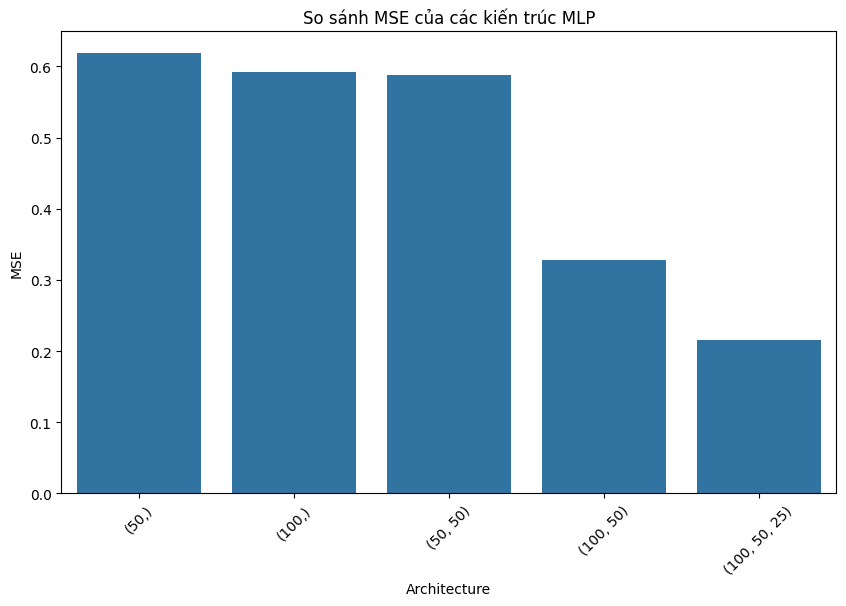

In [ ]:
from sklearn.neural_network import MLPRegressor
print("\n=== Kịch bản 1: Thử nghiệm với các kiến trúc MLP khác nhau (train:val = 7:3) ===")
mlp_architectures = [
    (50,),              # 1 lớp ẩn, 50 nơ-ron
    (100,),             # 1 lớp ẩn, 100 nơ-ron
    (50, 50),           # 2 lớp ẩn, mỗi lớp 50 nơ-ron
    (100, 50),          # 2 lớp ẩn, 100 và 50 nơ-ron
    (100, 50, 25)       #

]

results_mlp_arch = []
for arch in mlp_architectures:
    print(f"\nKiến trúc: {arch}")
    model = MLPRegressor(hidden_layer_sizes=arch, max_iter=10000, random_state=42, early_stopping=True)
    model.fit(X2_train, y2_train)

    y_pred = model.predict(X2_val)
    mse = mean_squared_error(y2_val, y_pred)
    r2 = r2_score(y2_val, y_pred)

    results_mlp_arch.append({
        'Architecture': str(arch),
        'MSE': mse,
        'R2': r2
    })

    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R-squared: {r2:.2%}')

# Tóm tắt kết quả MLP architectures
results_mlp_arch_df = pd.DataFrame(results_mlp_arch)
print("\nTóm tắt kết quả các kiến trúc MLP:")
print(results_mlp_arch_df)

# Vẽ biểu đồ so sánh MSE
plt.figure(figsize=(10, 6))
sns.barplot(x='Architecture', y='MSE', data=results_mlp_arch_df)
plt.title('So sánh MSE của các kiến trúc MLP')
plt.xticks(rotation=45)
plt.show()



=== Kịch bản 3: So sánh MLP với Random Forest (train:val = 7:3) ===

Mô hình: MLP
Mean Squared Error: 0.22
R-squared: 80.47%

Mô hình: Random Forest
Số đặc trưng được sử dụng (quan trọng > 0): 245 trên tổng 258
Mean Squared Error: 0.11
R-squared: 89.95%

Tóm tắt kết quả so sánh MLP và Random Forest:
           Model       MSE        R2
0            MLP  0.216042  0.804742
1  Random Forest  0.111179  0.899516


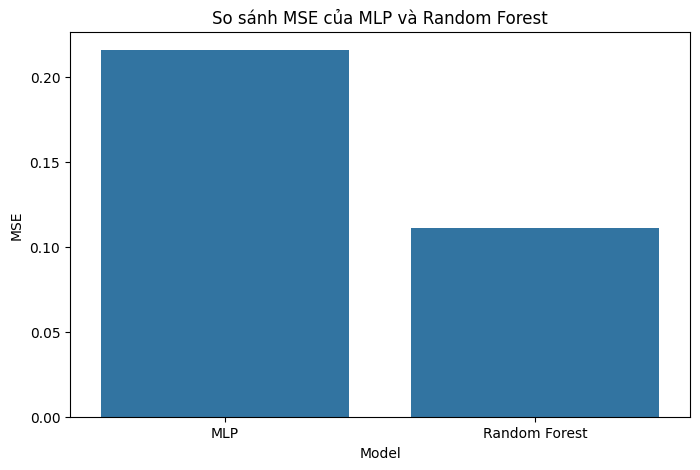

In [ ]:
from sklearn.ensemble import RandomForestRegressor
print("\n=== Kịch bản 3: So sánh MLP với Random Forest (train:val = 7:3) ===")
models = {
    'MLP': MLPRegressor(hidden_layer_sizes=(100,50,25), max_iter=10000, random_state=42, early_stopping=True),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}
results_compare = []
for name, model in models.items():
    print(f"\nMô hình: {name}")
    model.fit(X2_train, y2_train)
    y_pred = model.predict(X2_val)

    mse = mean_squared_error(y2_val, y_pred)
    r2 = r2_score(y2_val, y_pred)
    if(name == 'Random Forest'):
        importances = model.feature_importances_
        # Số đặc trưng quan trọng lớn hơn 0
        n_important = np.sum(importances > 0)
        print(f"Số đặc trưng được sử dụng (quan trọng > 0): {n_important} trên tổng {len(importances)}")
    results_compare.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R-squared: {r2:.2%}')

# Tóm tắt kết quả so sánh
results_compare_df = pd.DataFrame(results_compare)
print("\nTóm tắt kết quả so sánh MLP và Random Forest:")
print(results_compare_df)

# Vẽ biểu đồ so sánh MSE
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='MSE', data=results_compare_df)
plt.title('So sánh MSE của MLP và Random Forest')
plt.show()


=== Kịch bản 3: MLP với SalePrice log-transformed (train:val = 7:3) ===
Mean Squared Error (log-transformed): 5380787277.93
R-squared (log-transformed): 22.89%

Tóm tắt kết quả so sánh MLP với tập SalePrice log-transformed và tập ban đầu:
           du lieu           MSE        R2
0  log-transformed  5.380787e+09  0.228903
1              goc  7.237098e+08  0.896288


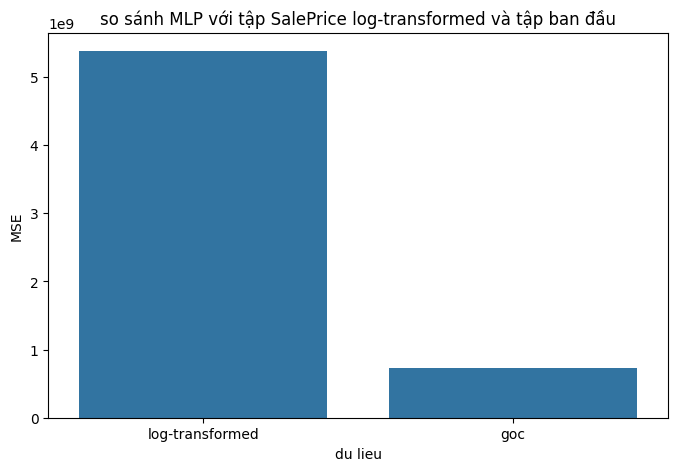

In [ ]:
print("\n=== Kịch bản 3: MLP với SalePrice log-transformed (train:val = 7:3) ===")
y_log = np.log1p(y)
X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.3, random_state=42)

model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=10000, random_state=42, early_stopping=True)
model.fit(X_train_log, y_train_log)

y_pred_log = model.predict(X_val_log)
y_pred = np.expm1(y_pred_log)
y_val_orig = np.expm1(y_val_log)

mse_log = mean_squared_error(y_val_orig, y_pred)
r2_log = r2_score(y_val_orig, y_pred)

print(f'Mean Squared Error (log-transformed): {mse_log:.2f}')
print(f'R-squared (log-transformed): {r2_log:.2%}')
result =pd.DataFrame ({'du lieu' : ['log-transformed','goc'],
    'MSE': [mse_log,mse],
    'R2': [r2_log,r2]
})

result_df = pd.DataFrame(result)
print("\nTóm tắt kết quả so sánh MLP với tập SalePrice log-transformed và tập ban đầu:")
print(result_df)

# Vẽ biểu đồ so sánh MSE
plt.figure(figsize=(8, 5))
sns.barplot(x='du lieu', y='MSE', data=result_df)
plt.title('so sánh MLP với tập SalePrice log-transformed và tập ban đầu')
plt.show()

In [ ]:
from sklearn.svm import SVR
model = SVR(kernel='linear', C=1000, epsilon=0.5, gamma=0.5)
model.fit(X2_train, y2_train)
y_pred_SVR = model.predict(X2_val)
mse = mean_squared_error(y2_val, y_pred_SVR)
r2 = r2_score(y2_val, y_pred_SVR)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2%}')


In [ ]:
from sklearn.svm import SVR
model = SVR(kernel='linear', C=1000, epsilon=0.1, gamma=0.1)
model.fit(X2_pca_train, y2_pca_train)
y2_pca_pred = model.predict(X2_pca_val)
mse2_pca = mean_squared_error(y2_pca_val, y2_pca_pred)
print(f'Mean Squared Error : {mse2_pca}')
r2_2_pca = r2_score(y2_pca_val, y2_pca_pred)
print(f'R-squared: {r2_2_pca:.2%}')

Mean Squared Error : 0.17171894966674478
R-squared: 84.48%
